In [21]:
import numpy as np
import pandas as pd
import tqdm.autonotebook as tqdm
from sklearn.metrics import pairwise, mean_squared_error
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestRegressor

from sklearn import datasets
from matplotlib import pyplot as plt
from scipy import spatial as sp

In [2]:
def y_rank_given_x_rank(x, y, x_rank=1):
    x_tree = sp.KDTree(x)
    y_tree = sp.KDTree(y)
    ds, ks = x_tree.query(x, k=2)
    ranks_y_k = np.zeros_like(y)
    for k in range(len(y)):
        dist = sp.distance.euclidean(y[k], y[ks[k, 1]])
        ranks_y_k[k] = len(y_tree.query_ball_point(y[k], dist))
    return ranks_y_k


def information_imbalance(x, y):
    ranks = y_rank_given_x_rank(x, y, x_rank=1)
    return 2 / y.shape[0] * np.mean(ranks)

In [3]:
def get_performance_pair(df, feature, target, pre_selected=None):
    feature_space = (pre_selected or []) + [feature]
    feat_to_target = information_imbalance(df[feature_space].values, df[[target]].values)
    target_to_feat = information_imbalance(df[[target]].values, df[feature_space].values)
    return pd.Series([feat_to_target, target_to_feat], index=["feat_to_target", "target_to_feat"])
    

In [4]:
def greedy_optimization(df, features, target):
    pre_selected = []
    imbalances = []
    for k in tqdm.trange(len(features)):
        non_selected = list(set(features) - set(pre_selected))
        current_imbalances = pd.DataFrame({
            feature: get_performance_pair(df, feature, target, pre_selected=pre_selected)
            for feature in tqdm.tqdm(non_selected)
        }).T
        best_feature = current_imbalances.sum(axis=1).idxmin()
        pre_selected = pre_selected + [best_feature]
        imbalances = imbalances + [current_imbalances.loc[best_feature]]
    return pre_selected, imbalances

In [5]:
def draw_diagonal(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)


In [6]:
data = datasets.fetch_california_housing()
features = data['feature_names']
target = data['target_names'][0]

df = pd.DataFrame(data['data'], columns=features)
df.loc[:, target] = data['target']

# df = df.sample(n=1000)

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
%time feature_order, imbalances = greedy_optimization(df, features, target)

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 5min 6s, sys: 30.7 s, total: 5min 37s
Wall time: 5min 38s


<AxesSubplot:>

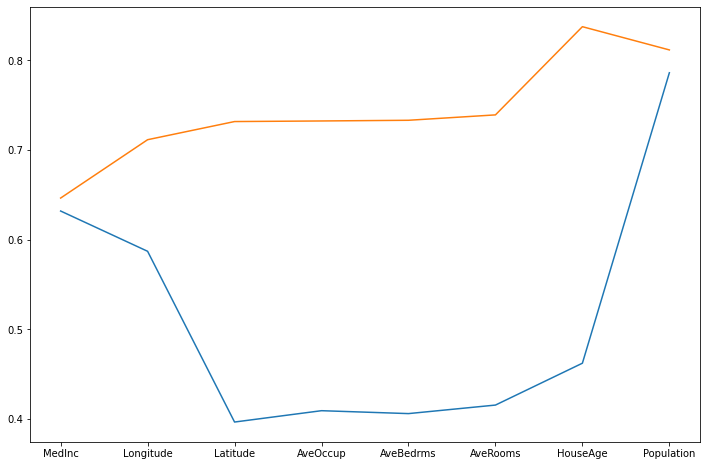

In [63]:
CV = 10
output = pd.DataFrame(index=feature_order, columns=range(CV))

for k in tqdm.trange(1, len(feature_order)+1):
    feature_set = feature_order[0:k]
    X = df.loc[:, feature_set]
    y = df.loc[:, target]
    model = RandomForestRegressor(n_estimators=1000, max_depth=10)
    scores = cross_validate(model, X, y, cv=CV)["test_score"]
    output.loc[feature_order[k-1]] = scores


  0%|          | 0/8 [00:00<?, ?it/s]

In [69]:
imbalances = pd.DataFrame(imbalances).loc[feature_order]

<AxesSubplot:>

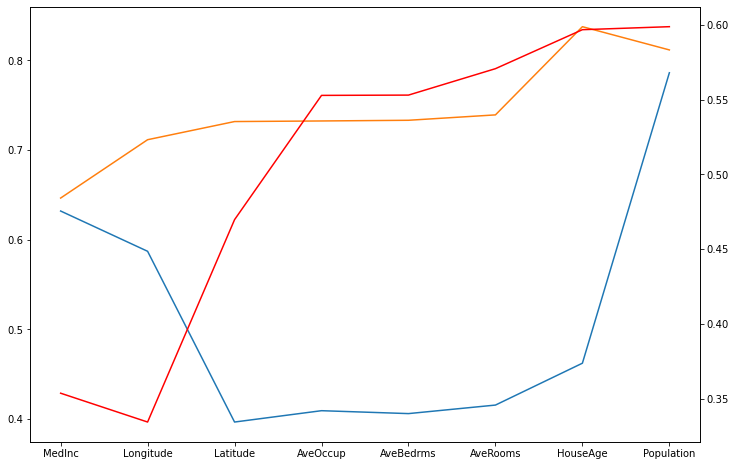

In [70]:
fig, ax = plt.subplots(figsize=(12, 8))
tax = ax.twinx()
output.mean(axis=1).plot(ax=tax, color="red")
imbalances.feat_to_target.plot(ax=ax)
imbalances.target_to_feat.plot(ax=ax)

In [77]:
para = imbalances.join(output.mean(axis=1).rename("performance"))

<AxesSubplot:>

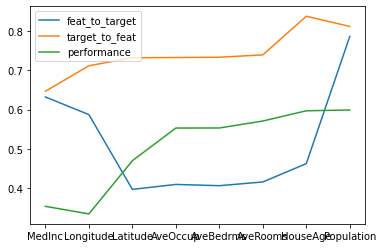

In [83]:
para.plot()